# Day 21 - Intro to ML

### Learning Objectives

After this class, students will be able to
- identify the key elements of a supervised ML system: data, model, parameters, loss function, training loop
- define "training" in ML

## Today's approach: 

### 1. Big Picture
We'll work mostly at the block-diagram level today. We'll slow down and open the blocks in future classes. You're always welcome to ask questions today! But I'll try to steer us towards big-picture thinking

### 2. Zero to ML, a step at a time
Many of you have seen ML fundamentals in other classes. You'll know many of the things we're doing today already. We'll begin by designing systems with serious flaws, and we'll fix them as we discover them. Please play along with the story, and don't drop spoilers too soon.

### 3. LLM assist
We're going to use LLMs today to support the goals above. It will help keep the emphasis on the big picture, not on the code.

In [17]:
ai_prompt = """
Background: This notebook is an in-class lesson in CSSE461, a senior-level Computer Vision 
course at RHIT. Today's lesson is the first lesson on machine learning for computer vision.
The lesson takes a high-level approach. Today we'll get the big picture. In future lessons
we'll dive into the details. 

Learning Objectives: Students should leave class today able to identify the key components 
and design choices in a machine learning system for computer vision: dataset, loss 
function, model architecture, training loop, and evaluation metrics. At a block-diagram
level, students should understand how these components fit together to form a complete
machine learning system.

Task description: Your task is to assist the lecture by providing individual components of
this system. We'll frame the lesson around image classification on CIFAR-10. Upon request, 
you will provide code snippets for each component of the system. Choose the simplest, most
idiomatic implementation possible that fulfills the requirements. Use PyTorch as the deep 
learning framework. Don't overdo the commenting, and keep your comments written for ML
beginners. We aren't concerned with maximizing performance today. Your goal is for the 
code you generate to be easy to understand, not cutting-edge.

Key constraint: I won't introduce test/train splits immediately. I'll start off with a 
single dataset. Of course, this is bad practice in real-world ML, but it's pedagogically
important that I don't try to answer questions that students aren't yet prepared to ask.
Until I say otherwise, always provide code that uses a single dataset for both training and 
evaluation.

Interaction style: When there are multiple design possibilities that satisfy the 
requirements above, go ahead and present 2 or 3 alternatives with a brief pros/cons list
for each. This is pedagogically useful. But don't offer complex alternatives when simple 
ones are sufficient.
"""

In [18]:
# I'm running today's lecture on a GPU server
# This line chooses which GPU I'll be running on. Run this line before any other imports. 
# To change GPUs, restart your kernel and then rerun this cell.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6" # Use this GPU


In [19]:
# All other imports go here:

In [20]:
# check if GPU compute is working
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

CUDA available: True
CUDA device: Quadro RTX 6000


### Plan for today:

- Get a dataset - CIFAR10. Explore and visualize.
- Create "Dataloaders"
- Write a simple neural network model
- Choose a loss function
- Write a simple training loop
- Train our model
- Evaluate the performance


#### Our Dataset: [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html)
Why?

- it's a vision dataset
- the vision problem (image classification) is relatively straightforward
- it's small enough we can do training runs live in class

pyTorch comes with several built-in datasets, ranging from quite small to very large. Let's use pytorch to load this dataset next.

In [21]:
# Load CIFAR-10 via Pytorch
import torchvision
import torchvision.transforms as transforms

# Convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load CIFAR-10
dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,      # We'll use the training set for everything today
    download=True, 
    transform=transform
)

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Dataset size: {len(dataset)} images")
print(f"Image shape: {dataset[0][0].shape}")  # (channels, height, width)

Dataset size: 50000 images
Image shape: torch.Size([3, 32, 32])


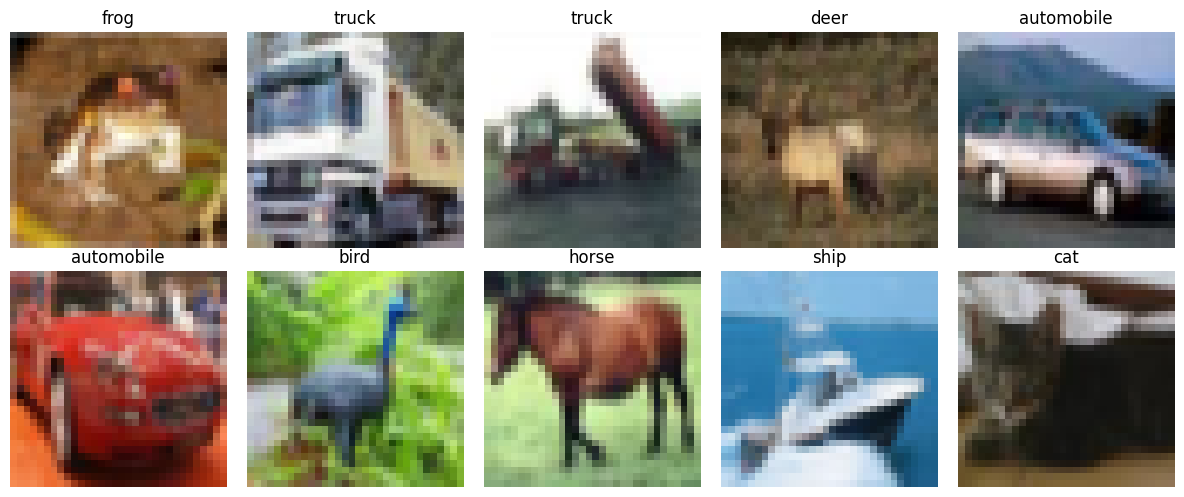

In [22]:
# Visualize some example input/output pairs from the dataset
import matplotlib.pyplot as plt

# Show a grid of example images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, label = dataset[i]
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Summary: What does it mean to train a model?

A model is a programmatically-defined function whose outputs depend on two things:

- An *input* (think, an image to process)
- *Parameters* (the coefficients in the huge list of equations that a model uses internally to process data)

Training is optimization: we're searching for a special set of *parameters* that cause the model to mostly give the right answers for most inputs.

<div>
<img src="https://imgs.xkcd.com/comics/machine_learning_2x.png" width="360"/>
</div>

Link: [xkcd 1838](https://xkcd.com/1838)

In [23]:
# Create a DataLoader to feed batches of data to our model
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=64,    # Number of images per batch
    shuffle=True      # Randomize order each epoch
)

print(f"Number of batches: {len(dataloader)}")
print(f"Batch size: {dataloader.batch_size}")

Number of batches: 782
Batch size: 64


In [24]:
# Define a simple CNN for image classification
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 input channels, 16 output
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 input, 32 output
        self.pool = nn.MaxPool2d(2, 2)  # Halves spatial dimensions
        self.relu = nn.ReLU()
        
        # Fully connected layers
        # After 2 pooling ops: 32x32 -> 16x16 -> 8x8, with 32 channels
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # -> 16 x 16 x 16
        x = self.pool(self.relu(self.conv2(x)))  # -> 32 x 8 x 8
        x = x.view(x.size(0), -1)                # Flatten to 1D
        x = self.relu(self.fc1(x))
        x = self.fc2(x)                          # Raw scores (logits)
        return x

# Create model and move to GPU
model = SimpleCNN().cuda()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [25]:
# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# CrossEntropyLoss combines:
#   1. Softmax (converts logits to probabilities)
#   2. Negative log-likelihood (penalizes wrong predictions)
# Higher confidence in wrong answer = bigger loss

In [26]:
# Optimizer: adjusts model parameters to minimize loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
num_epochs = 5

for epoch in range(num_epochs):
    running_loss = 0.0
    
    for images, labels in dataloader:
        # Move data to GPU
        images, labels = images.cuda(), labels.cuda()
        
        # Forward pass: compute predictions
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass: compute gradients
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Compute new gradients
        
        # Update parameters
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/5, Loss: 2.2764
Epoch 2/5, Loss: 2.0209
Epoch 3/5, Loss: 1.8484
Epoch 4/5, Loss: 1.7137
Epoch 5/5, Loss: 1.5842


In [27]:
# Compute accuracy on the dataset
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in dataloader:
        images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

Accuracy: 42.46% (21231/50000 correct)


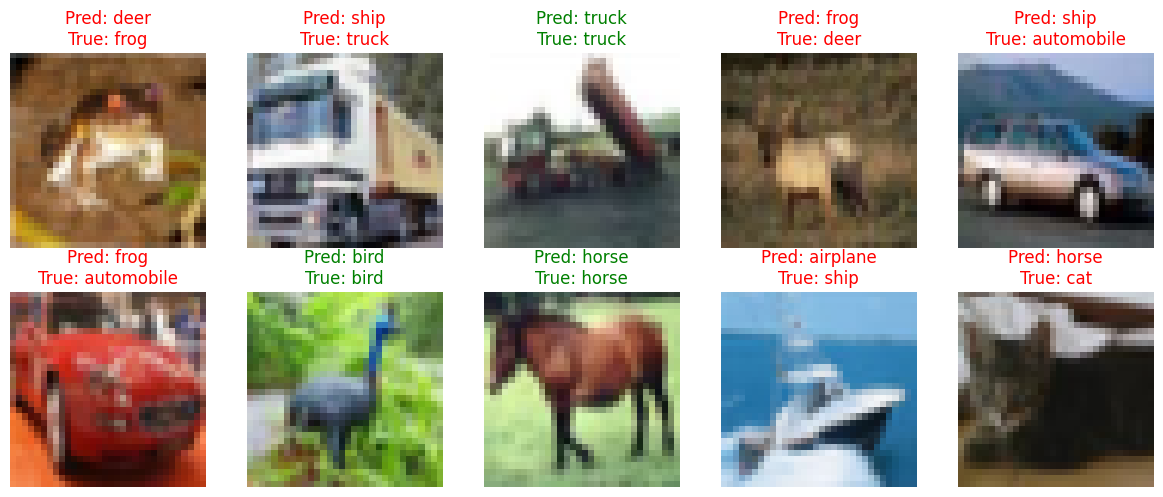

In [28]:
# Show some example predictions
model.eval()  # Switch to evaluation mode

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image, true_label = dataset[i]
    
    # Get model prediction
    with torch.no_grad():
        output = model(image.unsqueeze(0).cuda())  # Add batch dimension
        pred_label = output.argmax(dim=1).item()
    
    # Display image
    ax.imshow(image.permute(1, 2, 0))
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()